# Pre processamento

Pré-processamento dos dados de pesquisa no IEEE Xplore, Web Of Science e Scopus

#### Importação de pacotes

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

%matplotlib inline

#### Preâmbulo

1. PATHS

In [107]:
ROOT_DIR = os.path.abspath(os.path.join(os.curdir, '../../'))
input_path = os.path.join(ROOT_DIR, 'Build/Search2/Input')
output_path = os.path.join(ROOT_DIR, 'Build/Search2/Output')
img_path = os.path.join(output_path, 'Images')

2. CORES

In [108]:
grid_gray = '#E5E4E2'
warm1 = '#F94144'
warm2 = '#F3722C'
warm3 = '#F8961E'
warm4 = '#F9844A'
warm5 = '#F9C74F'
cold1 = '#90BE6D'
cold2 = '#43AA8B'
cold3 = '#4D908E'
cold4 = '#577590'
cold5 = '#277DA1'

3. DADOS

Foram feitos dois queries:

- Query 1: OPC UA e Security
- Query 2: Completo

In [109]:
edition_path = os.path.join(input_path, '2nd')
ieee_query1_raw = pd.read_csv(f'{edition_path}/IEEE-opcua_AND_security-K.csv')
ieee_query2_raw = pd.read_csv(f'{edition_path}/IEEE-opcua_AND_vul_OR-TAK.csv')
scopus_query1_raw = pd.read_csv(f'{edition_path}/SCOPUS-opcua_AND_security-K.csv')
scopus_query2_raw = pd.read_csv(f'{edition_path}/SCOPUS-opcua_AND_vul_OR-TAK.csv')
wos_query1_raw = pd.read_excel(f'{edition_path}/WOS-opcua_AND_security-K.xls')
wos_query2_raw = pd.read_excel(f'{edition_path}/WOS-opcua_AND_vul_OR-ALL.xls')

#### Remover colunas indesejadas

In [110]:
# === 2. Define columns explicitly for each source ===

# IEEE: Document Title, Authors, Publication Year, DOI, Document Identifier
ieee_columns_to_keep = ['Document Title', 'Authors', 'Publication Year', 'DOI', 'Document Identifier']

# Scopus: Title, Authors, Year, DOI, Document Type
scopus_columns_to_keep = ['Title', 'Authors', 'Year', 'DOI', 'Document Type']

# WOS: Article Title, Authors, Publication Year, DOI, Publication Type
wos_columns_to_keep = ['Article Title', 'Authors', 'Publication Year', 'DOI', 'Publication Type']

# === 3. Drop and rename for IEEE ===
ieee_query1_cln = ieee_query1_raw[ieee_columns_to_keep].copy()
ieee_query2_cln = ieee_query2_raw[ieee_columns_to_keep].copy()

ieee_query1 = ieee_query1_cln.rename(columns={
    'Document Title': 'Title',
    'Publication Year': 'Year',
    'Document Identifier': 'Document Type'
})

ieee_query2 = ieee_query2_cln.rename(columns={
    'Document Title': 'Title',
    'Publication Year': 'Year',
    'Document Identifier': 'Document Type'
})

# === 4. Drop for Scopus (columns are already named correctly) ===
scopus_query1 = scopus_query1_raw[scopus_columns_to_keep].copy()
scopus_query2 = scopus_query2_raw[scopus_columns_to_keep].copy()

# === 5. Drop and rename for WOS ===
wos_query1_cln = wos_query1_raw[wos_columns_to_keep].copy()
wos_query2_cln = wos_query2_raw[wos_columns_to_keep].copy()

wos_query1 = wos_query1_cln.rename(columns={
    'Article Title': 'Title',
    'Publication Year': 'Year',
    'Publication Type': 'Document Type'
})

wos_query2 = wos_query2_cln.rename(columns={
    'Article Title': 'Title',
    'Publication Year': 'Year',
    'Publication Type': 'Document Type'
})

# === 6. Final result: all six queries aligned with the same column names ===
final_columns = ['Title', 'Authors', 'Year', 'DOI', 'Document Type']
for df_name, df in zip(
    ['IEEE1', 'IEEE2', 'Scopus1', 'Scopus2', 'WOS1', 'WOS2'],
    [ieee_query1, ieee_query2, scopus_query1, scopus_query2, wos_query1, wos_query2]
):
    missing = [col for col in final_columns if col not in df.columns]
    if missing:
        print(f"⚠️ {df_name} is missing columns: {missing}")
    else:
        print(f"✅ {df_name} is ready and aligned.")
        # print(df[final_columns].head(2))  # Display the first few rows of each DataFrame

✅ IEEE1 is ready and aligned.
✅ IEEE2 is ready and aligned.
✅ Scopus1 is ready and aligned.
✅ Scopus2 is ready and aligned.
✅ WOS1 is ready and aligned.
✅ WOS2 is ready and aligned.


In [112]:
display(scopus_query2)

,Title,Authors,Year,DOI,Document Type
0,Industrial Protocol Security and Control Syste...,Visoky J.; Johnson W.,2022,10.24868/10711,Conference paper
1,"Towards Identifying Neglected, Obsolete, and A...",Yaben R.; Lundsgaard N.; August J.; Vasilomano...,2024,10.23919/TMA62044.2024.10558996,Conference paper
2,Design of an example network protocol for secu...,Pfrang S.; Giraud M.; Borcherding A.; Meier D....,2019,10.5220/0007704907270738,Conference paper
3,A review of PROFIBUS protocol vulnerabilities:...,Watson V.; Lou X.; Gao Y.,2017,10.5220/0006426504440449,Conference paper
4,Multi Agent Systems Based CPPS – An Industry 4...,Bendjelloul A.; Gaham M.; Bouzouia B.; Moufid ...,2022,10.1007/978-3-030-96311-8_18,Conference paper
5,Analysis of security vulnerability and measure...,Lee J.-K.; Shim J.-Y.; Lee K.-H.,2018,NaN,Article
6,Architecture for Enhancing Communication Secur...,Shin S.; Park M.; Kim T.; Yang H.,2024,10.3390/s24186000,Article
7,Throttled service calls in OPC UA,Ismail A.; Kastner W.,2018,10.1109/ICIT.2018.8352430,Conference paper
8,Design of Multi-Protocol Industrial Ethernet S...,Han D.; Zhao Y.; Gong Y.,2021,10.1109/ICPECA51329.2021.9362589,Conference paper
9,A meta model for a comprehensive description o...,Pfrang S.; Meier D.; Fleig A.; Beyerer J.,2020,NaN,Conference paper


#### Concatenar data frames e remover duplicados

In [113]:
# 1. Concatenate
query1_concat = pd.concat([ieee_query1, scopus_query1, wos_query1], ignore_index=True)
query2_concat = pd.concat([ieee_query2, scopus_query2, wos_query2], ignore_index=True)

# 2. Normalize Title for comparison (optional but helpful)
for df in [query1_concat, query2_concat]:
    df['Title_clean'] = df['Title'].str.strip().str.lower()

# 3. Remove duplicates based on DOI first (only where DOI is not null)
query1_dedup_doi = query1_concat.dropna(subset=['DOI']).drop_duplicates(subset=['DOI'])
query1_dedup_title = query1_concat[query1_concat['DOI'].isna()].drop_duplicates(subset=['Title_clean'])

# Combine both deduped sets
query1 = pd.concat([query1_dedup_doi, query1_dedup_title], ignore_index=True).drop(columns='Title_clean')
query1 = query1.sort_values(by='Title').reset_index(drop=True)

# Repeat for query2
query2_dedup_doi = query2_concat.dropna(subset=['DOI']).drop_duplicates(subset=['DOI'])
query2_dedup_title = query2_concat[query2_concat['DOI'].isna()].drop_duplicates(subset=['Title_clean'])

query2 = pd.concat([query2_dedup_doi, query2_dedup_title], ignore_index=True).drop(columns='Title_clean')
query2 = query2.sort_values(by='Title').reset_index(drop=True)


#### Dropando onde o ano é igual a 2025

In [114]:
query1 = query1[query1['Year'] != 2025].reset_index(drop=True)
query2 = query2[query2['Year'] != 2025].reset_index(drop=True)

#### Salvar em arquivos

In [115]:
query1.to_csv(f'{output_path}/query1.csv',sep=',',encoding='UTF-8')
query2.to_csv(f'{output_path}/query2.csv',sep=',',encoding='UTF-8')

## Resultados

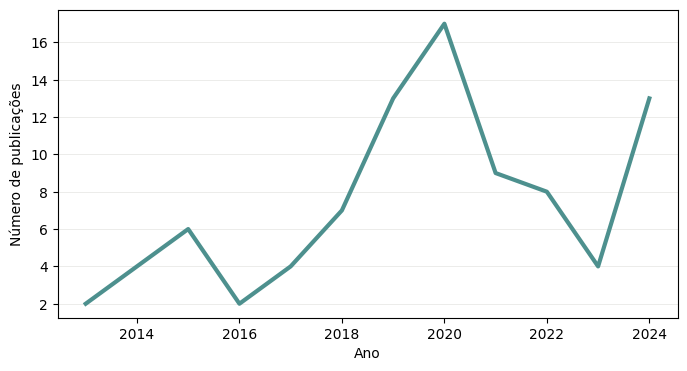

In [116]:
query1_grouped_by_year = query1.groupby('Year').size()

plt.figure(figsize=(8, 4))
query1_grouped_by_year.plot(kind='line', linestyle='-', color=cold3, linewidth=3)
plt.xlabel('Ano')
plt.ylabel('Número de publicações')
plt.grid(axis='y', color=grid_gray, linewidth=0.5)

# Ensure directory exists before saving the image
os.makedirs(img_path, exist_ok=True)

plt.savefig(f'{img_path}/pubAmount1.png', format='png', dpi=600)
plt.show()

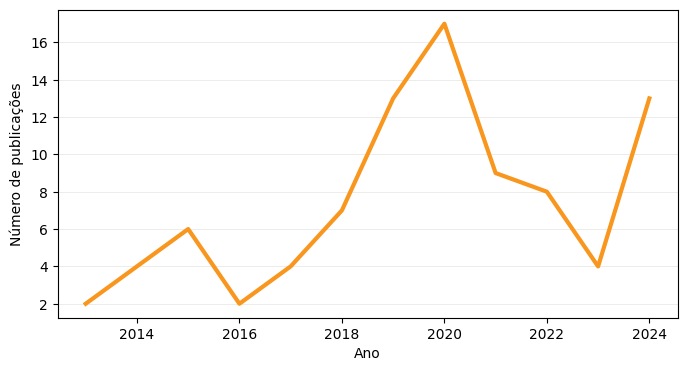

In [117]:
query1_grouped_by_year = query1.groupby('Year').size().reset_index(name='Count')
plt.figure(figsize=(8, 4))
sns.lineplot(data=query1_grouped_by_year, x='Year', y='Count', linestyle='-', color=warm3, linewidth=3)
plt.xlabel('Ano')
plt.ylabel('Número de publicações')
plt.grid(axis='y', color=grid_gray, linewidth=0.5)
plt.savefig(f'{img_path}/pubAmount2.png', format='png', dpi=600)
plt.show()

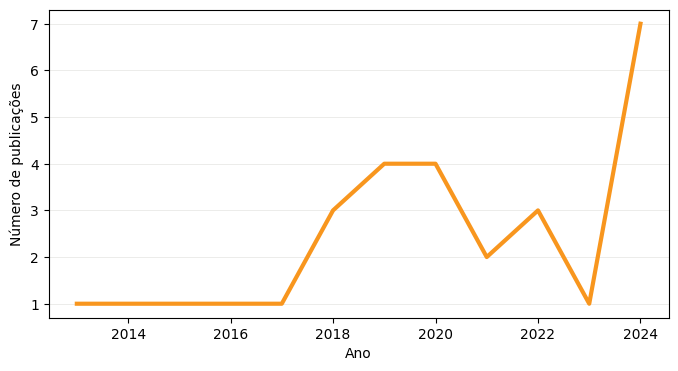

In [122]:
query2_grouped_by_year = query2.groupby('Year').size()
# query2_grouped_by_year
plt.figure(figsize=(8, 4))
query2_grouped_by_year.plot(kind='line', linestyle='-', color=warm3, linewidth=3)
plt.xlabel('Ano')
plt.ylabel('Número de publicações')
plt.grid(axis = 'y', color=grid_gray, linewidth=0.5)
plt.savefig(f'{img_path}/pubVulAmount.png', format='png', dpi=600)
plt.show()